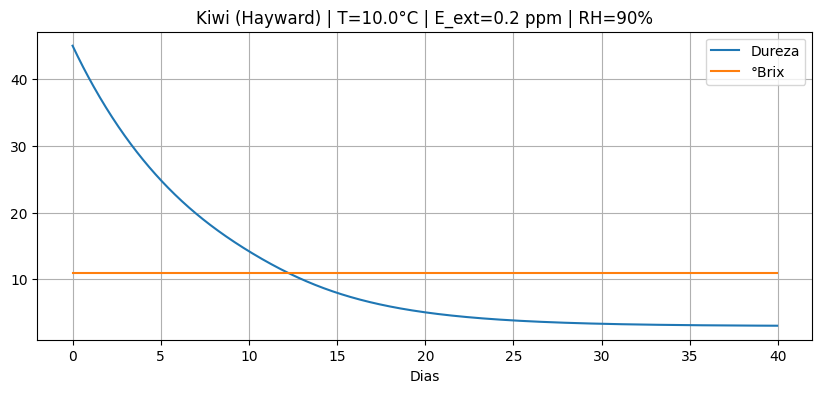

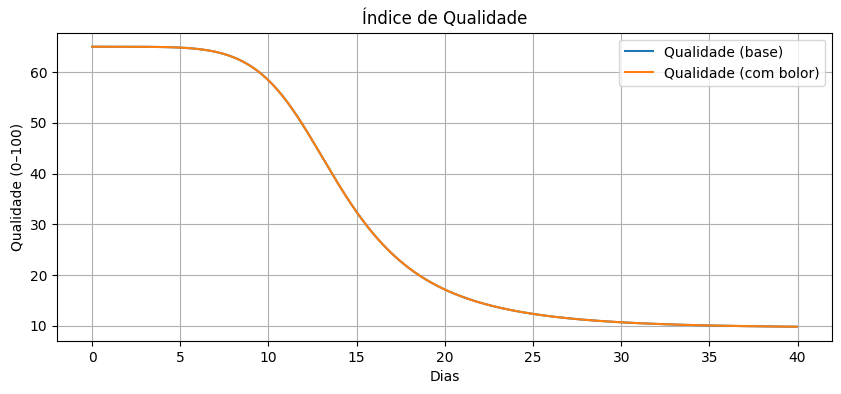

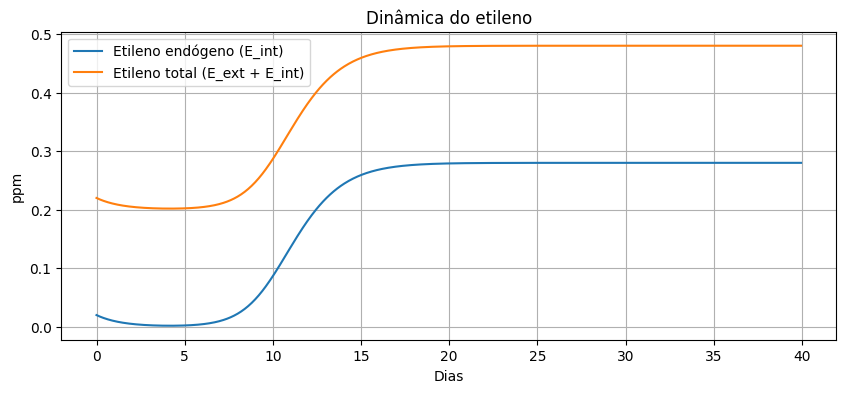

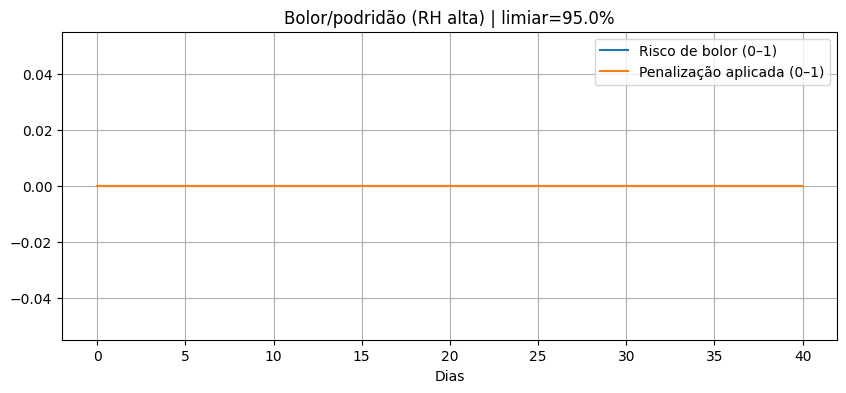

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# =============================================================================
# SIMULADOR DE PÓS-COLHEITA (didático)
# -----------------------------------------------------------------------------
# O que modela:
#   1) ETILENO endógeno (E_int): cresce ao longo do tempo em frutas climatéricas,
#      com rampa climatérica (sigmóide), autocatálise e degradação.
#      O utilizador controla o etileno EXTERNO (E_ext), que antecipa o gatilho.
#
#   2) DUREZA (amolecimento): modelo ODE
#         dD/dt = -k(t) * (D - D_min)
#      onde k(t) depende de temperatura (Arrhenius), etileno total (E_ext+E_int)
#      e humidade relativa (RH baixa acelera a perda de dureza por desidratação).
#
#   3) BRIX (doçura): modelo ODE logístico (não “químico”, mas coerente)
#         dB/dt = r(t) * x * (1 - x/K)    com x = B - B_min e K = B_max - B_min
#      r(t) cresce com temperatura e etileno total; RH baixa pode reduzir r.
#
#   4) BOLOR/PODRIDÃO (RH muito alta): estado mold(t) (0–1) que cresce quando
#      RH > limiar, acelerado por temperatura; penaliza a qualidade.
#
# IMPORTANTE:
#   - Unidades de "dureza" são "unidades arbitrárias" coerentes internamente.
#     (poderias mapear para N, kgf, etc. se calibrasses com dados reais)
#   - Os parâmetros por fruta são heurísticos e servem para simulação/ensino.
# =============================================================================


# =============================================================================
# 1) PRESETS POR FRUTA
# -----------------------------------------------------------------------------
# Cada fruta tem:
#
#   Termodinâmica / cinética:
#     - Tref_C      : temperatura de referência dos parâmetros (°C)
#     - Ea_J        : energia de ativação p/ amolecimento (J/mol)
#     - k_firm_ref  : taxa base de amolecimento a Tref (1/dia aprox)
#
#   Etileno e sensibilidade:
#     - alpha_E     : quanto o etileno total acelera o amolecimento (1/ppm)
#
#   Humidade:
#     - RH_ref      : RH "ideal" (ou típica de armazenamento) para essa fruta (%)
#     - beta_RH     : sensibilidade à RH baixa (desidratação) no amolecimento
#
#   Dureza:
#     - dureza_0_default : dureza típica no dia 0 (valor inicial sugerido)
#     - dureza_min       : limite mínimo (assíntota) de amolecimento
#
#   Brix:
#     - brix_0_default : brix típico no dia 0
#     - brix_min/max   : limites mínimos/máximos teóricos no modelo
#     - brix_g         : taxa base logística (não é “dias até maturação”)
#
#   Qualidade (índice 0–100):
#     - qual_firm_threshold : “limiar” de dureza considerado aceitável
#     - qual_brix_target    : brix "alvo" (pico do score de brix)
#
#   Etileno endógeno (produção interna):
#     - E0_int      : etileno interno inicial (ppm)
#     - Eref_prod   : produção máxima (ppm/dia) em Tref e após rampa
#     - E_t0        : dia em que arranca a fase climatérica (sem E_ext)
#     - E_g         : inclinação da sigmóide da rampa climatérica
#     - E_auto      : autocatálise (mais E -> mais produção)
#     - E_decay     : remoção/degradação (1/dia)
#     - Ea_E_J      : energia de ativação para a produção de etileno
#     - E_ext_shift : quanto E_ext antecipa o gatilho climatérico
#
#   Bolor/podridão (RH alta):
#     - RH_mold_thr     : limiar (%) a partir do qual há risco significativo
#     - mold_rate_ref   : taxa base de crescimento do bolor em Tref (1/dia)
#     - mold_sens_RH    : sensibilidade ao excedente de RH acima do limiar
#     - mold_max_penalty: penalização máxima na qualidade (0..1)
#     - Ea_mold_J       : energia de ativação para crescimento de bolor
# =============================================================================

PRESETS = {
    # -------------------------------------------------------------------------
    # KIWIS
    # -------------------------------------------------------------------------
    "kiwi_hayward": {
        "label": "Kiwi (Hayward)",
        # Amolecimento moderado; muito sensível ao etileno; armazena bem no frio
        "Tref_C": 5.0, "Ea_J": 60000, "k_firm_ref": 0.06, "alpha_E": 1.8,
        "beta_RH": 1.2, "RH_ref": 90,
        "dureza_min": 3,
        "dureza_0_default": 45,
        "brix_min": 11, "brix_max": 17, "brix_g": 0.35,
        "brix_0_default": 11.0,
        "qual_firm_threshold": 8, "qual_brix_target": 15,
        # Etileno endógeno (climatérico moderado)
        "E0_int": 0.02, "Eref_prod": 0.12, "E_t0": 10, "E_g": 0.9, "E_auto": 0.35,
        "E_decay": 0.70, "Ea_E_J": 52000, "E_ext_shift": 2.0,
    },
    "kiwi_baby": {
        "label": "Kiwi (Baby / Kiwi Berry)",
        # Muito mais rápido: casca fina, maior respiração, alta sensibilidade ao etileno
        "Tref_C": 4.0, "Ea_J": 58000, "k_firm_ref": 0.14, "alpha_E": 3.2,
        "beta_RH": 2.0, "RH_ref": 95,
        "dureza_min": 2,
        "dureza_0_default": 28,
        "brix_min": 13, "brix_max": 20, "brix_g": 0.50,
        "brix_0_default": 14.5,
        "qual_firm_threshold": 6, "qual_brix_target": 17,
        # Etileno endógeno (climatérico forte e cedo)
        "E0_int": 0.03, "Eref_prod": 0.22, "E_t0": 5, "E_g": 1.2, "E_auto": 0.55,
        "E_decay": 0.75, "Ea_E_J": 52000, "E_ext_shift": 2.6,
    },

    # -------------------------------------------------------------------------
    # MAÇÃS (cultivares)
    # -------------------------------------------------------------------------
    "maca_golden": {
        "label": "Maçã (Golden)",
        # “baseline” industrial; amadurecimento equilibrado
        "Tref_C": 5.0, "Ea_J": 50000, "k_firm_ref": 0.025, "alpha_E": 0.8,
        "beta_RH": 0.8, "RH_ref": 90,
        "dureza_min": 12, "dureza_0_default": 72,
        "brix_min": 11.5, "brix_max": 15.5, "brix_g": 0.18, "brix_0_default": 12.0,
        "qual_firm_threshold": 35, "qual_brix_target": 13.5,
        # Etileno moderado e tardio
        "E0_int": 0.01, "Eref_prod": 0.10, "E_t0": 18, "E_g": 0.6, "E_auto": 0.35,
        "E_decay": 0.55, "Ea_E_J": 52000, "E_ext_shift": 1.8,
    },
    "maca_reineta": {
        "label": "Maçã (Reineta)",
        # Perde textura mais cedo; amolecimento mais rápido e maior resposta ao etileno
        "Tref_C": 5.0, "Ea_J": 52000, "k_firm_ref": 0.035, "alpha_E": 1.1,
        "beta_RH": 1.0, "RH_ref": 90,
        "dureza_min": 10, "dureza_0_default": 65,
        "brix_min": 11.0, "brix_max": 14.0, "brix_g": 0.16, "brix_0_default": 11.5,
        "qual_firm_threshold": 30, "qual_brix_target": 12.5,
        "E0_int": 0.01, "Eref_prod": 0.13, "E_t0": 14, "E_g": 0.7, "E_auto": 0.40,
        "E_decay": 0.60, "Ea_E_J": 52000, "E_ext_shift": 2.0,
    },
    "maca_gala": {
        "label": "Maçã (Gala)",
        # Amadurece rápido; doçura sobe cedo; janela comercial curta
        "Tref_C": 5.0, "Ea_J": 48000, "k_firm_ref": 0.040, "alpha_E": 1.3,
        "beta_RH": 0.9, "RH_ref": 90,
        "dureza_min": 9, "dureza_0_default": 60,
        "brix_min": 12.5, "brix_max": 17.0, "brix_g": 0.25, "brix_0_default": 13.0,
        "qual_firm_threshold": 28, "qual_brix_target": 14.5,
        "E0_int": 0.015, "Eref_prod": 0.18, "E_t0": 10, "E_g": 0.9, "E_auto": 0.50,
        "E_decay": 0.65, "Ea_E_J": 52000, "E_ext_shift": 2.2,
    },
    "maca_fuji": {
        "label": "Maçã (Fuji)",
        # Muito estável: firme e doce; amadurecimento lento; baixa resposta ao etileno
        "Tref_C": 5.0, "Ea_J": 47000, "k_firm_ref": 0.018, "alpha_E": 0.6,
        "beta_RH": 0.7, "RH_ref": 90,
        "dureza_min": 15, "dureza_0_default": 80,
        "brix_min": 13.0, "brix_max": 19.0, "brix_g": 0.15, "brix_0_default": 14.0,
        "qual_firm_threshold": 40, "qual_brix_target": 16.0,
        "E0_int": 0.008, "Eref_prod": 0.06, "E_t0": 25, "E_g": 0.5, "E_auto": 0.25,
        "E_decay": 0.45, "Ea_E_J": 52000, "E_ext_shift": 1.4,
    },

    # -------------------------------------------------------------------------
    # CITRINOS / BANANA / BERRIES
    # -------------------------------------------------------------------------
    "laranja": {
        "label": "Laranja",
        # Não climatérica: etileno endógeno muito baixo; qualidade cai sobretudo por desidratação/tempo
        "Tref_C": 5.0, "Ea_J": 42000, "k_firm_ref": 0.010, "alpha_E": 0.15,
        "beta_RH": 0.35, "RH_ref": 90,
        "dureza_min": 35, "dureza_0_default": 55,
        "brix_min": 10.5, "brix_max": 13.5, "brix_g": 0.10, "brix_0_default": 11.5,
        "qual_firm_threshold": 42, "qual_brix_target": 12.2,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.80, "Ea_E_J": 40000, "E_ext_shift": 0.5,
    },
    "banana": {
        "label": "Banana",
        # Climatérica muito forte: “explosiva” em etileno e amolecimento
        "Tref_C": 14.0, "Ea_J": 65000, "k_firm_ref": 0.090, "alpha_E": 2.2,
        "beta_RH": 1.0, "RH_ref": 90,
        "dureza_min": 5, "dureza_0_default": 80,
        "brix_min": 12.0, "brix_max": 22.0, "brix_g": 0.45, "brix_0_default": 12.5,
        "qual_firm_threshold": 15, "qual_brix_target": 19,
        "E0_int": 0.02, "Eref_prod": 0.35, "E_t0": 4, "E_g": 1.4, "E_auto": 0.70,
        "E_decay": 0.90, "Ea_E_J": 60000, "E_ext_shift": 3.0,
    },
    "mirtilo": {
        "label": "Mirtilo",
        # Não climatérica; sensível à desidratação; bolor pode ser relevante a RH alta
        "Tref_C": 2.0, "Ea_J": 52000, "k_firm_ref": 0.030, "alpha_E": 0.10,
        "beta_RH": 1.6, "RH_ref": 95,
        "dureza_min": 6, "dureza_0_default": 30,
        "brix_min": 10.0, "brix_max": 14.0, "brix_g": 0.20, "brix_0_default": 11.5,
        "qual_firm_threshold": 12, "qual_brix_target": 12.5,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.90, "Ea_E_J": 42000, "E_ext_shift": 0.4,
    },
    "framboesa": {
        "label": "Framboesa",
        # Não climatérica; extremamente perecível; RH alta = muito risco de bolor
        "Tref_C": 2.0, "Ea_J": 56000, "k_firm_ref": 0.060, "alpha_E": 0.12,
        "beta_RH": 2.2, "RH_ref": 95,
        "dureza_min": 2.5, "dureza_0_default": 18,
        "brix_min": 7.0, "brix_max": 12.0, "brix_g": 0.22, "brix_0_default": 9.5,
        "qual_firm_threshold": 6, "qual_brix_target": 10.0,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.90, "Ea_E_J": 42000, "E_ext_shift": 0.4,
    },

    # -------------------------------------------------------------------------
    # PERA / AMEIXA / PÊSSEGO
    # -------------------------------------------------------------------------
    "pera": {
        "label": "Pera",
        # Climatérica; amolece rapidamente depois de arrancar; boa no frio
        "Tref_C": 2.0, "Ea_J": 54000, "k_firm_ref": 0.050, "alpha_E": 1.6,
        "beta_RH": 1.2, "RH_ref": 92,
        "dureza_min": 4, "dureza_0_default": 55,
        "brix_min": 10.5, "brix_max": 16.5, "brix_g": 0.28, "brix_0_default": 11.5,
        "qual_firm_threshold": 10, "qual_brix_target": 14.0,
        "E0_int": 0.01, "Eref_prod": 0.22, "E_t0": 10, "E_g": 1.0, "E_auto": 0.60,
        "E_decay": 0.75, "Ea_E_J": 56000, "E_ext_shift": 2.3,
    },
    "ameixa": {
        "label": "Ameixa",
        # Climatérica moderada; brix pode subir bem; risco de bolor moderado
        "Tref_C": 2.0, "Ea_J": 52000, "k_firm_ref": 0.060, "alpha_E": 1.0,
        "beta_RH": 1.0, "RH_ref": 92,
        "dureza_min": 3, "dureza_0_default": 40,
        "brix_min": 11.0, "brix_max": 20.0, "brix_g": 0.30, "brix_0_default": 12.5,
        "qual_firm_threshold": 8, "qual_brix_target": 16.5,
        "E0_int": 0.01, "Eref_prod": 0.14, "E_t0": 8, "E_g": 0.8, "E_auto": 0.45,
        "E_decay": 0.70, "Ea_E_J": 54000, "E_ext_shift": 2.0,
    },
    "pessego": {
        "label": "Pêssego",
        # Muito sensível a T e etileno; amolece rápido; risco de bolor pode subir
        "Tref_C": 2.0, "Ea_J": 56000, "k_firm_ref": 0.080, "alpha_E": 1.4,
        "beta_RH": 1.1, "RH_ref": 92,
        "dureza_min": 2, "dureza_0_default": 35,
        "brix_min": 9.5, "brix_max": 18.0, "brix_g": 0.35, "brix_0_default": 11.0,
        "qual_firm_threshold": 6, "qual_brix_target": 15.0,
        "E0_int": 0.012, "Eref_prod": 0.22, "E_t0": 6, "E_g": 1.0, "E_auto": 0.55,
        "E_decay": 0.80, "Ea_E_J": 56000, "E_ext_shift": 2.4,
    },

    # -------------------------------------------------------------------------
    # CEREJA / MORANGO / UVA / FIGO / MELÃO
    # -------------------------------------------------------------------------
    "cereja": {
        "label": "Cereja",
        # Não climatérica; etileno quase não influencia; RH alta pode aumentar bolor
        "Tref_C": 2.0, "Ea_J": 48000, "k_firm_ref": 0.045, "alpha_E": 0.05,
        "beta_RH": 1.6, "RH_ref": 95,
        "dureza_min": 4, "dureza_0_default": 28,
        "brix_min": 14.0, "brix_max": 20.0, "brix_g": 0.08, "brix_0_default": 16.0,
        "qual_firm_threshold": 10, "qual_brix_target": 18.0,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.90, "Ea_E_J": 42000, "E_ext_shift": 0.4,
    },
    "morango": {
        "label": "Morango",
        # Não climatérico; RH alta e T "morna" = bolor rápido; muito perecível
        "Tref_C": 2.0, "Ea_J": 52000, "k_firm_ref": 0.120, "alpha_E": 0.05,
        "beta_RH": 2.4, "RH_ref": 95,
        "dureza_min": 1.5, "dureza_0_default": 12,
        "brix_min": 6.0, "brix_max": 10.5, "brix_g": 0.12, "brix_0_default": 7.5,
        "qual_firm_threshold": 4.5, "qual_brix_target": 9.0,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.90, "Ea_E_J": 42000, "E_ext_shift": 0.4,
    },
    "uva": {
        "label": "Uva",
        # Não climatérica; RH baixa desidrata (passificação), RH alta pode aumentar bolor
        "Tref_C": 2.0, "Ea_J": 45000, "k_firm_ref": 0.020, "alpha_E": 0.05,
        "beta_RH": 1.8, "RH_ref": 92,
        "dureza_min": 3, "dureza_0_default": 20,
        "brix_min": 14.0, "brix_max": 22.0, "brix_g": 0.05, "brix_0_default": 16.0,
        "qual_firm_threshold": 7, "qual_brix_target": 18.0,
        "E0_int": 0.002, "Eref_prod": 0.01, "E_t0": 999, "E_g": 0.2, "E_auto": 0.0,
        "E_decay": 0.90, "Ea_E_J": 42000, "E_ext_shift": 0.4,
    },
    "figo": {
        "label": "Figo",
        # Muito perecível; mesmo sem ser tão “etileno-driven” quanto banana, degrada muito depressa
        "Tref_C": 2.0, "Ea_J": 52000, "k_firm_ref": 0.110, "alpha_E": 0.20,
        "beta_RH": 1.8, "RH_ref": 95,
        "dureza_min": 1.2, "dureza_0_default": 10,
        "brix_min": 14.0, "brix_max": 26.0, "brix_g": 0.18, "brix_0_default": 16.0,
        "qual_firm_threshold": 3.5, "qual_brix_target": 20.0,
        "E0_int": 0.005, "Eref_prod": 0.05, "E_t0": 12, "E_g": 0.5, "E_auto": 0.15,
        "E_decay": 0.70, "Ea_E_J": 52000, "E_ext_shift": 1.0,
    },
    "melao": {
        "label": "Melão",
        # Depende do tipo; aqui como climatérico moderado
        "Tref_C": 7.0, "Ea_J": 52000, "k_firm_ref": 0.060, "alpha_E": 0.9,
        "beta_RH": 0.9, "RH_ref": 90,
        "dureza_min": 2.0, "dureza_0_default": 25,
        "brix_min": 9.0, "brix_max": 16.0, "brix_g": 0.22, "brix_0_default": 10.5,
        "qual_firm_threshold": 6.0, "qual_brix_target": 13.5,
        "E0_int": 0.01, "Eref_prod": 0.10, "E_t0": 10, "E_g": 0.7, "E_auto": 0.35,
        "E_decay": 0.70, "Ea_E_J": 52000, "E_ext_shift": 1.8,
    },
}

# =============================================================================
# 2) PARÂMETROS DE BOLOR POR FRUTA (defaults + overrides)
# -----------------------------------------------------------------------------
# Objetivo: refletir que certas frutas (morango/framboesa/figo) estragam com bolor
# muito rapidamente a RH alta, enquanto maçãs/kiwis/citrinos são mais resistentes.
# =============================================================================

MOLD_DEFAULTS = {
    "RH_mold_thr": 95.0,        # RH (%) a partir do qual começa risco significativo
    "mold_rate_ref": 0.06,      # taxa base (1/dia) em Tref
    "mold_sens_RH": 10.0,       # sensibilidade ao excedente de RH acima do limiar
    "mold_max_penalty": 0.80,   # máximo de penalização (0..1)
    "Ea_mold_J": 45000.0,       # sensibilidade à temperatura (Arrhenius)
}

MOLD_BY_FRUIT = {
    # Muito sensíveis
    "morango":   {"RH_mold_thr": 93.0, "mold_rate_ref": 0.22, "mold_sens_RH": 16.0, "mold_max_penalty": 0.95, "Ea_mold_J": 52000.0},
    "framboesa": {"RH_mold_thr": 93.0, "mold_rate_ref": 0.20, "mold_sens_RH": 16.0, "mold_max_penalty": 0.95, "Ea_mold_J": 52000.0},
    "figo":      {"RH_mold_thr": 93.0, "mold_rate_ref": 0.18, "mold_sens_RH": 14.0, "mold_max_penalty": 0.92, "Ea_mold_J": 50000.0},

    # Sensíveis
    "mirtilo":   {"RH_mold_thr": 94.0, "mold_rate_ref": 0.12, "mold_sens_RH": 14.0, "mold_max_penalty": 0.90, "Ea_mold_J": 48000.0},
    "cereja":    {"RH_mold_thr": 94.0, "mold_rate_ref": 0.10, "mold_sens_RH": 13.0, "mold_max_penalty": 0.85, "Ea_mold_J": 47000.0},
    "pessego":   {"RH_mold_thr": 94.0, "mold_rate_ref": 0.10, "mold_sens_RH": 12.0, "mold_max_penalty": 0.85, "Ea_mold_J": 48000.0},
    "ameixa":    {"RH_mold_thr": 94.0, "mold_rate_ref": 0.09, "mold_sens_RH": 12.0, "mold_max_penalty": 0.82, "Ea_mold_J": 47000.0},

    # Médio
    "pera":      {"RH_mold_thr": 95.0, "mold_rate_ref": 0.07, "mold_sens_RH": 10.0, "mold_max_penalty": 0.75, "Ea_mold_J": 45000.0},
    "melao":     {"RH_mold_thr": 95.0, "mold_rate_ref": 0.08, "mold_sens_RH": 10.0, "mold_max_penalty": 0.78, "Ea_mold_J": 45000.0},
    "uva":       {"RH_mold_thr": 95.0, "mold_rate_ref": 0.08, "mold_sens_RH": 11.0, "mold_max_penalty": 0.80, "Ea_mold_J": 45000.0},

    # Baixo a médio (kiwis/maçãs)
    "kiwi_hayward": {"RH_mold_thr": 95.0, "mold_rate_ref": 0.05,  "mold_sens_RH": 9.0,  "mold_max_penalty": 0.65, "Ea_mold_J": 43000.0},
    "kiwi_baby":    {"RH_mold_thr": 95.0, "mold_rate_ref": 0.07,  "mold_sens_RH": 10.0, "mold_max_penalty": 0.75, "Ea_mold_J": 45000.0},
    "maca_golden":  {"RH_mold_thr": 95.0, "mold_rate_ref": 0.04,  "mold_sens_RH": 8.0,  "mold_max_penalty": 0.60, "Ea_mold_J": 42000.0},
    "maca_reineta": {"RH_mold_thr": 95.0, "mold_rate_ref": 0.05,  "mold_sens_RH": 9.0,  "mold_max_penalty": 0.65, "Ea_mold_J": 43000.0},
    "maca_gala":    {"RH_mold_thr": 95.0, "mold_rate_ref": 0.05,  "mold_sens_RH": 9.0,  "mold_max_penalty": 0.65, "Ea_mold_J": 43000.0},
    "maca_fuji":    {"RH_mold_thr": 95.0, "mold_rate_ref": 0.035, "mold_sens_RH": 8.0,  "mold_max_penalty": 0.55, "Ea_mold_J": 42000.0},

    # Baixo (citrinos)
    "laranja": {"RH_mold_thr": 96.0, "mold_rate_ref": 0.03, "mold_sens_RH": 8.0, "mold_max_penalty": 0.50, "Ea_mold_J": 42000.0},
}

# Aplica defaults e depois overrides por fruta
for k in PRESETS:
    for kk, vv in MOLD_DEFAULTS.items():
        PRESETS[k].setdefault(kk, vv)
    if k in MOLD_BY_FRUIT:
        PRESETS[k].update(MOLD_BY_FRUIT[k])


# =============================================================================
# 3) UI (widgets)
# =============================================================================
fruit_widget = widgets.Dropdown(
    options=[(v["label"], k) for k, v in PRESETS.items()],
    value="kiwi_hayward",
    description="Fruta:",
)

temp_widget = widgets.FloatSlider(
    value=10.0, min=0.0, max=25.0, step=0.5,
    description="Temp (°C):",
    continuous_update=False
)

# Etileno EXTERNO (câmara/ambiente). O etileno INTERNO é calculado no modelo.
ethylene_widget = widgets.FloatSlider(
    value=0.2, min=0.0, max=10.0, step=0.1,
    description="Etileno ext (ppm):",
    continuous_update=False
)

# RH = Humidade Relativa (%)
rh_widget = widgets.IntSlider(
    value=90, min=40, max=100, step=1,
    description="RH (%):",
    continuous_update=False
)

days_widget = widgets.IntSlider(
    value=40, min=5, max=180, step=5,
    description="Dias:",
    continuous_update=False
)

# Valores iniciais (t=0) ajustáveis: mudam automaticamente com a fruta
dureza0_widget = widgets.FloatText(description="Dureza (dia 0):")
brix0_widget   = widgets.FloatText(description="°Brix (dia 0):")

run_button = widgets.Button(description="Run simulation", button_style="success")

ui = widgets.VBox([
    fruit_widget,
    temp_widget,
    ethylene_widget,
    rh_widget,
    days_widget,
    widgets.HTML("<b>Valores iniciais típicos (ajustáveis) — t=0</b>"),
    dureza0_widget,
    brix0_widget,
    run_button
])

display(ui)

def set_initials_from_fruit(fruit_key: str):
    """Ao mudar de fruta no dropdown, atualiza os defaults de dureza e brix no dia 0."""
    p = PRESETS[fruit_key]
    dureza0_widget.value = float(p["dureza_0_default"])
    brix0_widget.value   = float(p["brix_0_default"])

set_initials_from_fruit(fruit_widget.value)

def _on_fruit_changed(change):
    if change["name"] == "value":
        set_initials_from_fruit(change["new"])

fruit_widget.observe(_on_fruit_changed, names="value")


# =============================================================================
# 4) SIMULAÇÃO (Etileno endógeno + Bolor por RH alta)
# =============================================================================
def run_simulation(fruit_key, T_c, E_ext_ppm, RH_pct, days, dureza_0_user, brix_0_user):
    import numpy as np
    import matplotlib.pyplot as plt

    dt = 0.05  # passo temporal (dias). 0.05 ~ 1.2 horas.
    R = 8.314  # constante dos gases (J/mol/K)

    def k_temp_scaling(Ea, T, Tref):
        """
        Escalonamento tipo Arrhenius relativo a uma temperatura de referência.
        devolve fator multiplicativo.
        """
        return np.exp((-Ea / R) * (1/T - 1/Tref))

    def sigmoid(x):
        """Sigmóide clássica."""
        return 1.0 / (1.0 + np.exp(-x))

    p = PRESETS[fruit_key]
    t = np.arange(0, days, dt)

    # -------------------------------------------------------------------------
    # 4.1) Efeito da temperatura no amolecimento (kT_firm)
    # -------------------------------------------------------------------------
    T_K = T_c + 273.15
    Tref_K = p["Tref_C"] + 273.15

    # k_firm_ref é a taxa de amolecimento em Tref
    # Ea_J controla quão depressa k cresce com a temperatura
    kT_firm = p["k_firm_ref"] * k_temp_scaling(p["Ea_J"], T_K, Tref_K)

    # -------------------------------------------------------------------------
    # 4.2) Efeito da RH baixa no amolecimento (desidratação)
    # -------------------------------------------------------------------------
    RH_ref = p["RH_ref"]  # RH "ideal/típica" para minimizar desidratação
    RH_deficit = max(0.0, (RH_ref - RH_pct) / 100.0)
    kRH = (1 + p["beta_RH"] * RH_deficit)  # RH baixa => kRH > 1 => amolece mais rápido

    # -------------------------------------------------------------------------
    # 4.3) ETILENO ENDÓGENO (E_int) e etileno total
    # -------------------------------------------------------------------------
    # Modelo:
    #   dE/dt = prod(t)*(1 + E_auto*E) - E_decay*E
    # prod(t) tem rampa sigmóide (climatérica) e aumenta com T.
    E_int = np.zeros_like(t)
    E_int[0] = float(p.get("E0_int", 0.01))

    Ea_E_J = float(p.get("Ea_E_J", 52000))
    Eref_prod = float(p.get("Eref_prod", 0.08))     # produção máxima (ppm/dia)
    E_decay = float(p.get("E_decay", 0.7))          # remoção (1/dia)
    E_t0 = float(p.get("E_t0", 15.0))               # gatilho sem E_ext (dias)
    E_g = float(p.get("E_g", 0.8))                  # inclinação do gatilho
    E_auto = float(p.get("E_auto", 0.35))           # autocatálise
    E_ext_shift = float(p.get("E_ext_shift", 2.0))  # E_ext antecipa o gatilho

    # Etileno externo antecipa o gatilho climatérico (mais E_ext -> t0 menor)
    t0_eff = E_t0 - E_ext_shift * np.log1p(max(0.0, E_ext_ppm))

    # Produção de etileno aumenta com T (usamos Ea_E_J)
    prod_T = k_temp_scaling(Ea_E_J, T_K, Tref_K)

    for i in range(1, len(t)):
        ramp = sigmoid(E_g * (t[i-1] - t0_eff))      # 0..1
        prod = Eref_prod * prod_T * ramp             # ppm/dia
        dE = (prod * (1.0 + E_auto * E_int[i-1]) - E_decay * E_int[i-1]) * dt
        E_int[i] = max(0.0, E_int[i-1] + dE)

    # Etileno total que influencia amadurecimento
    E_total = E_ext_ppm + E_int

    # -------------------------------------------------------------------------
    # 4.4) DUREZA (amolecimento) via ODE
    # -------------------------------------------------------------------------
    # dD/dt = -k(t) * (D - D_min), com k(t) = kT_firm * kRH * (1 + alpha_E * E_total)
    dureza = np.zeros_like(t)
    dureza_min = float(p["dureza_min"])
    dureza[0] = max(dureza_min + 1e-6, float(dureza_0_user))

    alpha_E = float(p["alpha_E"])
    for i in range(1, len(t)):
        kE = (1.0 + alpha_E * E_total[i-1])
        k = kT_firm * kRH * kE
        dD = (-k * (dureza[i-1] - dureza_min)) * dt
        dureza[i] = max(dureza_min, dureza[i-1] + dD)

    # -------------------------------------------------------------------------
    # 4.5) BRIX (doçura) via ODE logística
    # -------------------------------------------------------------------------
    # db/dt = r(t) * x * (1 - x/K), com x = b - b_min, K = b_max - b_min
    brix = np.zeros_like(t)
    brix_min = float(p["brix_min"])
    brix_max = float(p["brix_max"])
    brix[0] = float(brix_0_user)

    r0 = float(p["brix_g"])      # taxa base
    alpha_bE = 0.25              # etileno acelera conversões (heurístico)

    # RH baixa pode reduzir a “eficiência” (stress/desidratação)
    bRH = max(0.0, (RH_ref - RH_pct) / 100.0)
    rRH = (1.0 - 0.6 * bRH)

    # Efeito da temperatura na taxa de brix (usando Ea_E_J como aproximação)
    rT = k_temp_scaling(Ea_E_J, T_K, Tref_K)

    for i in range(1, len(t)):
        r = r0 * rT * rRH * (1.0 + alpha_bE * E_total[i-1])
        x = max(0.0, brix[i-1] - brix_min)
        K = max(1e-6, (brix_max - brix_min))
        db = (r * x * (1.0 - x / K)) * dt
        brix[i] = min(brix_max, max(brix_min, brix[i-1] + db))

    # -------------------------------------------------------------------------
    # 4.6) QUALIDADE base (0–100)
    # -------------------------------------------------------------------------
    firm_score = 1 / (1 + np.exp(-0.35 * (dureza - float(p["qual_firm_threshold"]))))
    brix_score = np.exp(-((brix - float(p["qual_brix_target"]))**2) / 2)
    quality_base = 100 * (0.65 * firm_score + 0.35 * brix_score)

    # -------------------------------------------------------------------------
    # 4.7) BOLOR / PODRIDÃO (RH alta)
    # -------------------------------------------------------------------------
    # mold(t) cresce quando RH > RH_mold_thr:
    #   dm/dt = rate * (1 - m)
    # rate aumenta com temperatura e com excedente de RH.
    RH_mold_thr = float(p["RH_mold_thr"])
    mold_rate_ref = float(p["mold_rate_ref"])
    mold_sens_RH = float(p["mold_sens_RH"])
    mold_max_penalty = float(p["mold_max_penalty"])
    Ea_mold_J = float(p["Ea_mold_J"])

    mold_T = k_temp_scaling(Ea_mold_J, T_K, Tref_K)
    RH_excess = max(0.0, (RH_pct - RH_mold_thr) / 100.0)
    RH_factor = 1.0 - np.exp(-mold_sens_RH * RH_excess)  # 0..~1

    mold = np.zeros_like(t)
    mold[0] = 0.0
    for i in range(1, len(t)):
        rate = mold_rate_ref * mold_T * RH_factor
        dm = (rate * (1.0 - mold[i-1])) * dt
        mold[i] = min(1.0, max(0.0, mold[i-1] + dm))

    mold_penalty = mold_max_penalty * mold
    quality = quality_base * (1.0 - mold_penalty)

    # -------------------------------------------------------------------------
    # 4.8) Gráficos
    # -------------------------------------------------------------------------
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,4))
    plt.plot(t, dureza, label="Dureza")
    plt.plot(t, brix, label="°Brix")
    plt.legend()
    plt.xlabel("Dias")
    plt.title(f"{p['label']} | T={T_c}°C | E_ext={E_ext_ppm} ppm | RH={RH_pct}%")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(t, quality_base, label="Qualidade (base)")
    plt.plot(t, quality, label="Qualidade (com bolor)")
    plt.ylabel("Qualidade (0–100)")
    plt.xlabel("Dias")
    plt.title("Índice de Qualidade")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(t, E_int, label="Etileno endógeno (E_int)")
    plt.plot(t, E_total, label="Etileno total (E_ext + E_int)")
    plt.ylabel("ppm")
    plt.xlabel("Dias")
    plt.title("Dinâmica do etileno")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(t, mold, label="Risco de bolor (0–1)")
    plt.plot(t, mold_penalty, label="Penalização aplicada (0–1)")
    plt.xlabel("Dias")
    plt.title(f"Bolor/podridão (RH alta) | limiar={RH_mold_thr}%")
    plt.grid()
    plt.legend()
    plt.show()


def on_run_clicked(_):
    run_simulation(
        fruit_widget.value,
        temp_widget.value,
        ethylene_widget.value,
        rh_widget.value,
        days_widget.value,
        dureza0_widget.value,
        brix0_widget.value
    )

run_button.on_click(on_run_clicked)